# Phase 4 — Geophysical Fluid Dynamics: Shallow Water and Quasi-Geostrophy

This final chapter assembles everything from the earlier phases — the [staggered grid](arakawa_cgrid.ipynb), the [discrete operators](operators.ipynb), the [elliptic solver](phase2_spatial.ipynb) — into the two model families at the heart of somax: the **rotating shallow-water** equations and their slow-manifold reduction, the **quasi-geostrophic** equations. Rotation is the new physics: it introduces the Coriolis force, geostrophic balance, the deformation radius, and the westward-propagating Rossby waves that organise the ocean's large-scale circulation {cite}`vallis2017atmospheric,cushman2011introduction,pedlosky1987geophysical`.

**What you will learn**

- How a free-surface bump adjusts toward geostrophic balance, radiating gravity waves
- What geostrophic balance means for the velocity and height fields
- How a quasi-geostrophic flow conserves potential vorticity while shedding Rossby waves

## 1. The rotating shallow-water equations

The single-layer rotating shallow-water equations evolve a height field $h$ and horizontal velocity $\mathbf{u}=(u,v)$ on an $f$-plane,

```{math}
:label: p4-swm-momentum
\partial_t \mathbf{u} + (\mathbf{u}\cdot\nabla)\mathbf{u} + f\,\hat{\mathbf{z}}\times\mathbf{u}
  = -g\,\nabla h ,
```

```{math}
:label: p4-swm-mass
\partial_t h + \nabla\cdot(h\,\mathbf{u}) = 0 ,
```

where $f$ is the Coriolis parameter and $g$ gravity. The Coriolis term $f\,\hat{\mathbf{z}}\times\mathbf{u}$ turns moving fluid to the right (northern hemisphere) and is what distinguishes geophysical flow from the [cavity flow](phase2_spatial.ipynb) of Phase 2. The fastest signal is the external gravity wave with speed $c=\sqrt{gH}$, which sets the CFL limit for an explicit run.

In [1]:
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import importlib.util
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import (
    BarotropicQG,
    BarotropicQGState,
    NonlinearShallowWater2D,
    NonlinearSW2DState,
)

In [2]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,jax,matplotlib,somax")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

watermark extension not installed; skipping reproducibility readout.


In [3]:
IMG_DIR = Path.cwd().parent / "images" / "phase4_gfd"
IMG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Geostrophic adjustment

Release a mound of fluid in a rotating system and it does *not* simply collapse. Rotation arrests the spreading: the flow accelerates down the pressure gradient, is deflected by Coriolis, and settles into a balance in which the pressure gradient is held up by the Coriolis force — **geostrophic balance**,

```{math}
:label: p4-geostrophy
f\,u = -g\,\partial_y h, \qquad f\,v = g\,\partial_x h .
```

The excess height that cannot be balanced is radiated away as gravity waves, leaving a balanced vortex behind. The horizontal scale over which adjustment happens is the **Rossby radius of deformation** $L_d = \sqrt{gH}/f$. We initialise a Gaussian sea-surface-height bump at rest and integrate.

In [4]:
swm = NonlinearShallowWater2D.create(
    nx=96,
    ny=96,
    Lx=2e6,
    Ly=2e6,
    f0=1e-4,
    H0=1000.0,
    lateral_viscosity=50.0,
    bc="periodic",
)
xs = jnp.arange(swm.grid.Nx) * swm.grid.dx
ys = jnp.arange(swm.grid.Ny) * swm.grid.dy
Xs, Ys = jnp.meshgrid(xs, ys)
bump = 2.0 * jnp.exp(-(((Xs - 1e6) ** 2 + (Ys - 1e6) ** 2) / (2e5) ** 2))
swm_state0 = NonlinearSW2DState(
    h=swm.consts.H0 + bump, u=jnp.zeros_like(bump), v=jnp.zeros_like(bump)
)

# Gravity-wave CFL: c = sqrt(g H0); keep dt so c*dt/dx < 1/2.
c_ext = jnp.sqrt(9.81 * swm.consts.H0)
dx_min = min(swm.grid.dx, swm.grid.dy)
print(f"external wave speed sqrt(gH) = {float(c_ext):.0f} m/s, dx = {dx_min:.0f} m")
Ld = float(c_ext) / swm.consts.f0
print(f"deformation radius L_d = sqrt(gH)/f = {Ld / 1e3:.0f} km")

swm_sol = swm.integrate(swm_state0, t0=0.0, t1=2 * 86400.0, dt=100.0, max_steps=40000)
h_final = swm_sol.ys.h[-1]
diag_final = swm.diagnose(
    NonlinearSW2DState(h=h_final, u=swm_sol.ys.u[-1], v=swm_sol.ys.v[-1])
)

external wave speed sqrt(gH) = 99 m/s, dx = 20833 m
deformation radius L_d = sqrt(gH)/f = 990 km


{numref}`p4-adjustment-fig` compares the initial height anomaly with the field after two days. The central bump has partially slumped and is now encircled by a balanced geostrophic flow (shown as the velocity vorticity), with concentric gravity-wave fronts radiating outward through the periodic domain.

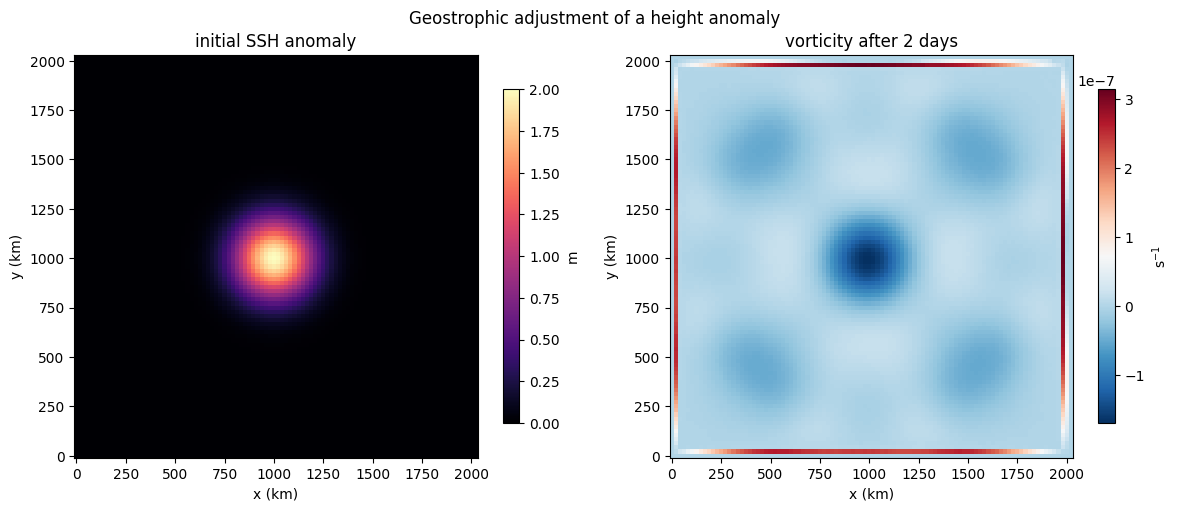

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].pcolormesh(Xs / 1e3, Ys / 1e3, bump, cmap="magma", shading="auto")
axes[0].set(
    xlabel="x (km)", ylabel="y (km)", title="initial SSH anomaly", aspect="equal"
)
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="m")
im1 = axes[1].pcolormesh(
    Xs / 1e3,
    Ys / 1e3,
    diag_final.relative_vorticity,
    cmap="RdBu_r",
    shading="auto",
)
axes[1].set(
    xlabel="x (km)", ylabel="y (km)", title="vorticity after 2 days", aspect="equal"
)
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="s$^{-1}$")
fig.suptitle("Geostrophic adjustment of a height anomaly")
fig.tight_layout()
fig.savefig(IMG_DIR / "geostrophic_adjustment.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase4_gfd/geostrophic_adjustment.png
:label: p4-adjustment-fig
:width: 95%

Geostrophic adjustment in the rotating shallow-water model {eq}`p4-swm-momentum`–{eq}`p4-swm-mass`. Left: the initial sea-surface-height bump. Right: the relative vorticity after two days — a balanced rotating vortex has formed around the residual mound while gravity waves carry off the excess.
```

## 3. Quasi-geostrophy and potential-vorticity dynamics

When the flow is slow compared to rotation (small Rossby number $\mathrm{Ro}=U/fL\ll 1$), the gravity waves filter out and the dynamics collapse onto a single prognostic scalar: the **quasi-geostrophic potential vorticity** (PV). For the barotropic model,

```{math}
:label: p4-qgpv
\partial_t q + J(\psi, q) = 0,
\qquad q = \nabla^2\psi + \beta y,
```

where $\psi$ is the streamfunction, $J$ the advective Jacobian, and $\beta=\mathrm{d}f/\mathrm{d}y$ the planetary vorticity gradient. PV is *materially conserved* — advected, not created — and the velocity is recovered from $\psi$ by the same Poisson inversion $\nabla^2\psi=q-\beta y$ seen in [Phase 2](phase2_spatial.ipynb). somax discretises the Jacobian with the energy- and enstrophy-conserving Arakawa scheme {cite}`arakawa1977computational`. We seed a vortex pair and let it self-advect.

In [6]:
qg = BarotropicQG.create(
    nx=96, ny=96, Lx=1e6, Ly=1e6, f0=1e-4, beta=1.6e-11, lateral_viscosity=50.0
)
xq = jnp.arange(qg.grid.Nx) * qg.grid.dx
yq = jnp.arange(qg.grid.Ny) * qg.grid.dy
Xq, Yq = jnp.meshgrid(xq, yq)
radius = 8e4
q0 = 1e-4 * (
    jnp.exp(-(((Xq - 6e5) ** 2 + (Yq - 5e5) ** 2) / radius**2))
    - jnp.exp(-(((Xq - 4e5) ** 2 + (Yq - 5e5) ** 2) / radius**2))
)
qg_state0 = qg.apply_boundary_conditions(BarotropicQGState(q=q0))

qg_sol = qg.integrate(qg_state0, t0=0.0, t1=5 * 86400.0, dt=900.0, max_steps=20000)
q_final = qg_sol.ys.q[-1]
qg_diag = qg.diagnose(BarotropicQGState(q=q_final))

{numref}`p4-qg-fig` shows the PV field after five days alongside the recovered streamfunction. The dipole has translated and sheared under mutual advection while conserving PV; the streamfunction contours are the instantaneous streamlines of the balanced flow.

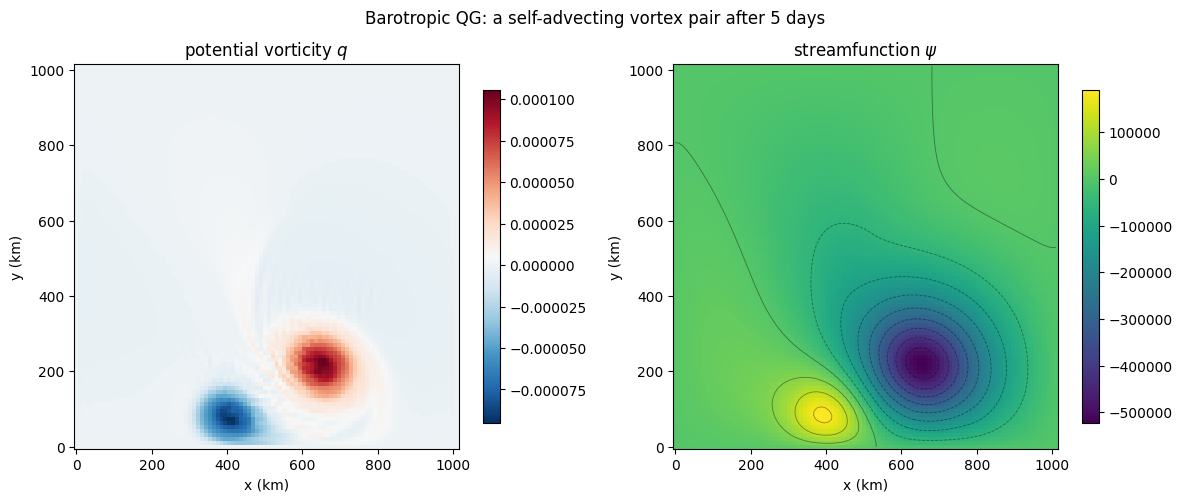

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].pcolormesh(Xq / 1e3, Yq / 1e3, q_final, cmap="RdBu_r", shading="auto")
axes[0].set(
    xlabel="x (km)", ylabel="y (km)", title="potential vorticity $q$", aspect="equal"
)
fig.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].pcolormesh(
    Xq / 1e3, Yq / 1e3, qg_diag.psi, cmap="viridis", shading="auto"
)
axes[1].contour(
    Xq / 1e3, Yq / 1e3, qg_diag.psi, levels=12, colors="k", alpha=0.4, linewidths=0.6
)
axes[1].set(
    xlabel="x (km)", ylabel="y (km)", title=r"streamfunction $\psi$", aspect="equal"
)
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.suptitle("Barotropic QG: a self-advecting vortex pair after 5 days")
fig.tight_layout()
fig.savefig(IMG_DIR / "qg_vortex.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase4_gfd/qg_vortex.png
:label: p4-qg-fig
:width: 95%

Barotropic quasi-geostrophic evolution {eq}`p4-qgpv` of a vortex pair. Left: the materially-conserved PV after five days. Right: the streamfunction from the Poisson inversion, whose contours are the streamlines of the balanced flow.
```

## Summary

- The rotating shallow-water equations {eq}`p4-swm-momentum`–{eq}`p4-swm-mass` add the Coriolis force; their fastest signal, the external gravity wave $c=\sqrt{gH}$, sets the explicit CFL limit.
- **Geostrophic adjustment** {eq}`p4-geostrophy` is the defining rotating behaviour: a pressure anomaly settles into a balanced vortex of scale $L_d=\sqrt{gH}/f$ while radiating gravity waves.
- The **quasi-geostrophic** reduction {eq}`p4-qgpv` filters the waves and reduces the dynamics to material advection of potential vorticity, recovered through the same elliptic inversion built in Phase 2 — the foundation of the multilayer ocean models and the data-assimilation studies that follow.

This completes the Phase 0–4 arc: from staggered grids and discrete operators, through the 1-D and 2-D building blocks and low-order chaos, to the rotating geophysical models that somax exists to solve. For running these models as configured simulations, see the [somax-sim runner tutorial](composable_models_terms_operators_cycles.ipynb); for correcting them against observations, the [data-assimilation tutorials](data_assimilation_etkf.ipynb).